In [57]:
import math

import torch
import matplotlib.pyplot as plt

seqlen = 100
nembed = 128

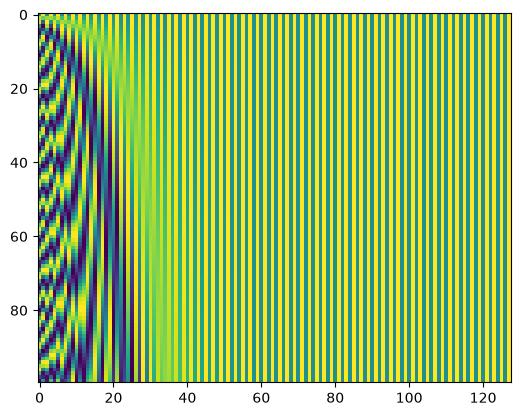

In [128]:
# The original positional embedding from "Attention is All You Need"

p = torch.zeros((seqlen, nembed))

for i in range(seqlen):
    for t in range(nembed // 2):
        p[i, 2*t] = math.sin(i / 10000**(2*t / 64))
        p[i, 2*t + 1] = math.cos(i / 10000**(2*t / 64))

plt.imshow(p);  # Semicolon to avoid pyplot repr printing

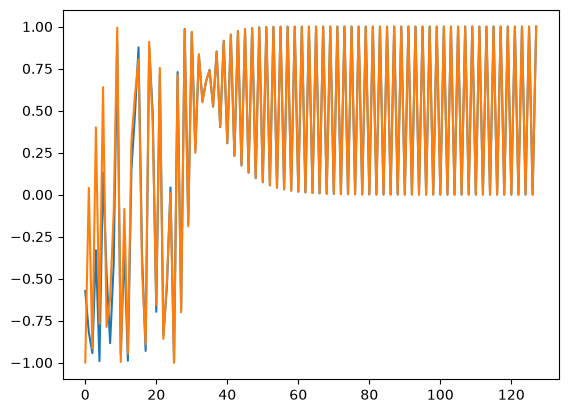

In [129]:
for i in [98, 99]:  # Encodings for t=98 & t=99
    plt.plot(p[i])

In [131]:
print((p[ 0] * p[ 2]).sum().item())
print((p[50] * p[51]).sum().item())  # Relative inner products are different

60.303863525390625
62.916831970214844


In [86]:
def plot_3d(tensor):
    X, Y = torch.meshgrid(
        torch.arange(tensor.size(1)),
        torch.arange(tensor.size(0)),
        indexing="xy",
    )
    fig = plt.figure()
    ax = fig.add_subplot(111, projection="3d")
    ax.plot_surface(X, Y, tensor, cmap="viridis")
    ax.set_xlabel("dim")
    ax.set_ylabel("time")
    ax.set_zlabel("theta")
    plt.show()


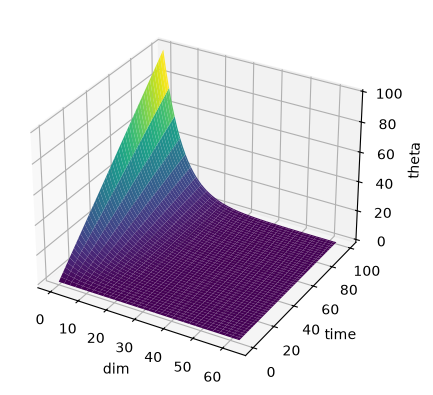

In [87]:
# Rotary positional embedding embedding from "RoFormer: Enhanced Transformer With Rotary Position Embedding"

x = torch.ones(nembed)

f = (10000. * torch.ones(nembed // 2))**(-2 * torch.arange(nembed // 2).float() / nembed)
f = torch.outer(torch.arange(seqlen), f)
plot_3d(f)  # Rotation angles across all time in every dimension

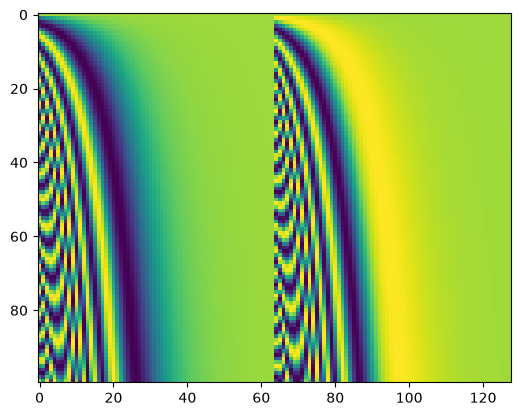

In [114]:
f_c = torch.polar(torch.ones_like(f), f)
x_c = torch.view_as_complex(torch.stack(x.chunk(2, -1), -1))
r = torch.cat(torch.split(torch.view_as_real(f_c * x_c), 1, -1), -2).squeeze(-1)
plt.imshow(r);  # Rotated embedding vector

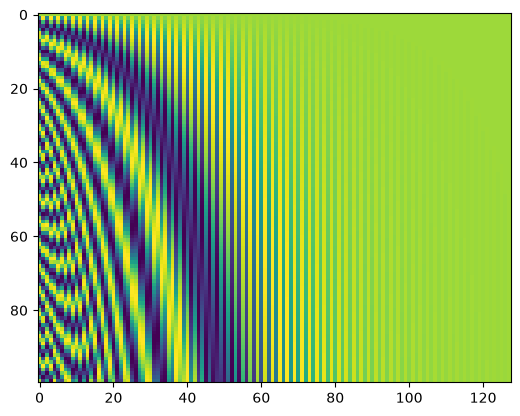

In [115]:
r_vis = torch.stack((r[:, :nembed//2], r[:, nembed//2:]), -1).view(100, -1)
plt.imshow(r_vis);

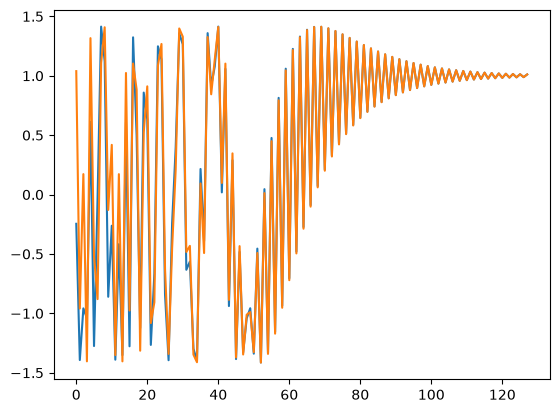

In [118]:
for i in [98, 99]:
    plt.plot(r_vis[i])

In [132]:
print((r_vis[ 0] * r_vis[ 1]).sum().item())
print((r_vis[50] * r_vis[51]).sum().item())  # Relative inner products are identical

124.18736267089844
124.18736267089844
